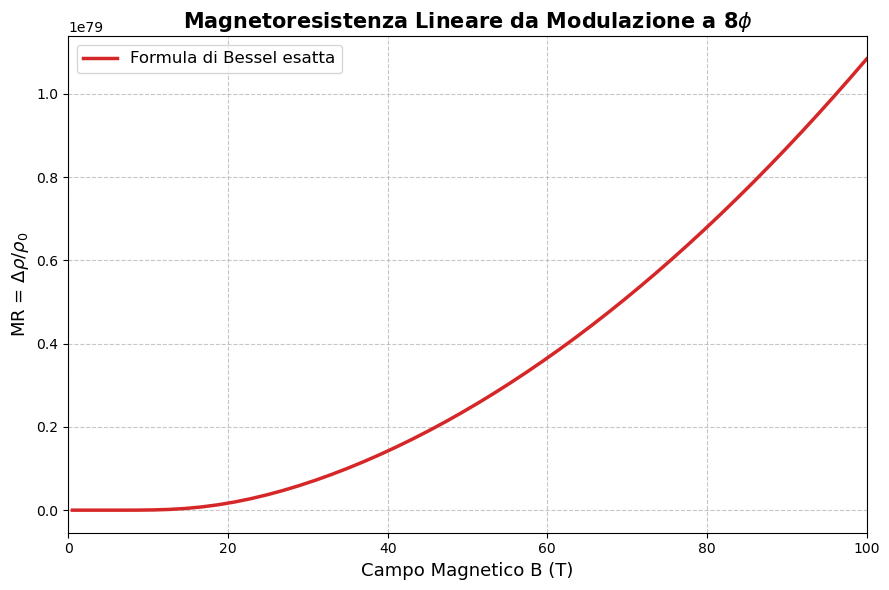

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ive

def user_formula_sigma_xx(B, Gamma_is=3, Gamma_an=42.0, m_eff=1):
    """
    Calcola la conducibilità sigma_xx usando l'espansione esatta
    di Jacobi-Anger e le regole di selezione analitiche.
    """
    # 1. Frequenza di ciclotrone (in meV)
    w = 0.1158 * B / m_eff
    
    # 2. Parametro di accoppiamento alfa
    alpha = Gamma_an / (8 * w)
    
    # 3. Taglio dinamico per la sommatoria
    # La ghigliottina del fattoriale: non serve sommare fino a infinito,
    # ci fermiamo in modo intelligente poco dopo che n supera alpha.
    N = int(max(20, 3.0 * np.sqrt(alpha)))
    N = min(N, 100) # Limite massimo di sicurezza per le performance
    
    n_vals = np.arange(-N, N+1)
    
    # 4. Calcolo vettorializzato delle funzioni di Bessel (scalate esponenzialmente)
    ive_alpha = ive(n_vals, alpha)
    ive_alpha_8 = ive(n_vals, alpha/8)
    
    # Dizionari per un accesso istantaneo durante i cicli annidati
    ive_a_dict = {n: ive_alpha[i] for i, n in enumerate(n_vals)}
    ive_a8_dict = {n: ive_alpha_8[i] for i, n in enumerate(n_vals)}
    
    # Indici per k = -n - 2m - 2j (che può essere più grande di N)
    k_vals = np.arange(-5*N, 5*N+1)
    ive_k_arr = ive(k_vals, alpha)
    ive_k_dict = {k: ive_k_arr[i] for i, k in enumerate(k_vals)}
    
    S = 0.0 # Variabile dove accumuliamo la sommatoria
    
    # 5. La tripla sommatoria (k è stato eliminato dalla tua Delta!)
    for n in n_vals:
        iv_n = ive_a_dict[n]
        if iv_n < 1e-12: continue # Salta i termini numericamente nulli
        
        for m in n_vals:
            iv_m = ive_a8_dict[m]
            if iv_n * iv_m < 1e-12: continue
            
            for j in n_vals:
                iv_j = ive_a8_dict[j]
                
                # La tua regola di selezione (Delta di Kronecker applicata)
                k = -n - 2*m - 2*j
                if k not in ive_k_dict:
                    continue
                iv_k = ive_k_dict[k]
                
                # Prodotto delle 4 funzioni di Bessel
                val = iv_n * iv_m * iv_k * iv_j
                if val < 1e-12: continue
                
                # --- LA TUA MAGIA DELLE FASI COMPLESSE ---
                # Calcolo esatto di: (-1)^{n+j} * (-i)^{m+j}
                p = (m+j)//2
                sign_nj = 1.0 if (n+j)%2 == 0 else -1.0
                sign_p = 1.0 if p%2 == 0 else -1.0
                
                if (m+j) % 2 == 0:
                    phase = sign_nj * sign_p         # Caso PARI: puramente reale
                else:
                    phase = sign_nj * sign_p * (-1j) # Caso DISPARI: immaginario puro
                    
                # Il denominatore analitico (la risonanza)
                denom = Gamma_is + 1j * w * (1 + 4*n + 8*m)
                
                # Parte reale della frazione moltiplicata per il peso delle Bessel
                term = val * np.real(phase / denom)
                S += term
                
    # Moltiplichiamo per l'esponenziale compensativo (poiché abbiamo usato `ive`)
    # Gli argomenti totali estratti erano: alpha + alpha/8 + alpha + alpha/8 = 2.25 * alpha
    return S * np.exp(2.25 * alpha)


# ==========================================
# CALCOLO DELLA CURVA E CREAZIONE DEL PLOT
# ==========================================

# Vettore dei campi magnetici (partiamo da 0.5 T per evitare divisione per zero in alpha)
B_vals = np.linspace(0.5, 100, 50)

# Calcolo della conducibilità per ogni B
sigma_vals = np.array([user_formula_sigma_xx(B) for B in B_vals])

# Calcolo della Magnetoresistenza (MR = rho(B)/rho(0) - 1 = sigma(0)/sigma(B) - 1)
# Usiamo la conducibilità a 0.5 T come riferimento per il campo base
sigma_0 = user_formula_sigma_xx(0.5)
MR_vals = sigma_0 / sigma_vals - 1

# Impostazioni del grafico
plt.figure(figsize=(9, 6))
plt.plot(B_vals, MR_vals, color='#d62728', linewidth=2.5, label='Formula di Bessel esatta')
plt.title('Magnetoresistenza Lineare da Modulazione a 8$\phi$', fontsize=15, fontweight='bold')
plt.xlabel('Campo Magnetico B (T)', fontsize=13)
plt.ylabel(r'MR = $\Delta\rho / \rho_0$', fontsize=13)
plt.xlim(0, 100)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()

# Mostra il grafico a schermo
plt.show()

C:\Users\vikra\AppData\Local\Temp\ipykernel_6864\3629319814.py:66: RuntimeWarning: overflow encountered in exp
  return S * np.exp(2.25 * alpha)
C:\Users\vikra\AppData\Local\Temp\ipykernel_6864\3629319814.py:90: RuntimeWarning: invalid value encountered in divide
  MR_vals = (sigma_0 / sigma_vals) - 1.0


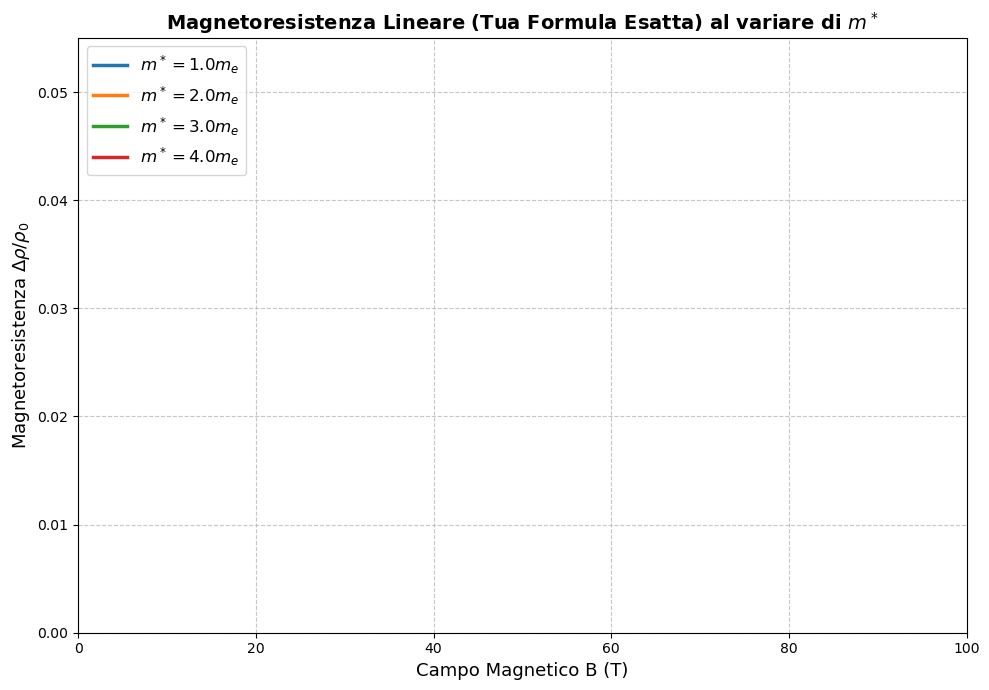

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ive

def calc_sigma_xx_bessel(B, Gamma_is, Gamma_an, m_eff):
    """
    Calcola la conducibilità usando la tua formula esatta 
    basata sulle funzioni di Bessel e parità degli indici.
    """
    # Evitiamo divisioni per zero a B=0
    if B < 1e-4:
        B = 1e-4
        
    w = 0.1158 * B / m_eff
    alpha = Gamma_an / (8.0 * w)
    
    # Taglio dinamico: basta sommare fino a poco oltre alpha
    N = int(max(15, 2.5 * np.sqrt(alpha)))
    N = min(N, 50) 
    
    n_vals = np.arange(-N, N+1)
    ive_alpha = ive(n_vals, alpha)
    ive_alpha_8 = ive(n_vals, alpha/8.0)
    
    ive_a_dict = {n: ive_alpha[i] for i, n in enumerate(n_vals)}
    ive_a8_dict = {n: ive_alpha_8[i] for i, n in enumerate(n_vals)}
    
    k_vals = np.arange(-5*N, 5*N+1)
    ive_k_arr = ive(k_vals, alpha)
    ive_k_dict = {k: ive_k_arr[i] for i, k in enumerate(k_vals)}
    
    S = 0.0
    for n in n_vals:
        iv_n = ive_a_dict[n]
        if iv_n < 1e-10: continue
        
        for m in n_vals:
            iv_m = ive_a8_dict[m]
            if iv_n * iv_m < 1e-10: continue
            
            for j in n_vals:
                iv_j = ive_a8_dict[j]
                
                k = -n - 2*m - 2*j
                if k not in ive_k_dict: continue
                iv_k = ive_k_dict[k]
                
                val = iv_n * iv_m * iv_k * iv_j
                if val < 1e-10: continue
                
                # Fasi complessa e distinzione pari/dispari
                p = (m+j)//2
                sign_nj = 1.0 if (n+j)%2 == 0 else -1.0
                sign_p = 1.0 if p%2 == 0 else -1.0
                
                if (m+j) % 2 == 0:
                    phase = sign_nj * sign_p
                else:
                    phase = sign_nj * sign_p * (-1j)
                    
                denom = Gamma_is + 1j * w * (1.0 + 4.0*n + 8.0*m)
                
                term = val * np.real(phase / denom)
                S += term
                
    return S * np.exp(2.25 * alpha)

# ==========================================
# SETUP DEI PARAMETRI E PLOT
# ==========================================

# I tuoi parametri base (mev)
Gamma_is = 3.0
Gamma_an = 42.0

# Vettore dei campi magnetici (fino a 100 Tesla)
B_vals = np.linspace(0.1, 100, 40)

# Masse efficaci da testare per fittare i dati di Giovanni
masse_test = [1.0, 2.0, 3.0, 4.0]

plt.figure(figsize=(10, 7))

# Calcoliamo la curva per ogni massa
for m in masse_test:
    sigma_vals = np.array([calc_sigma_xx_bessel(B, Gamma_is, Gamma_an, m) for B in B_vals])
    
    # La magnetoresistenza è normalizzata sul primo valore (H -> 0)
    sigma_0 = sigma_vals[0]
    MR_vals = (sigma_0 / sigma_vals) - 1.0
    
    plt.plot(B_vals, MR_vals, linewidth=2.5, label=f'$m^* = {m} m_e$')

# Grafica e stile
plt.title('Magnetoresistenza Lineare (Tua Formula Esatta) al variare di $m^*$', fontsize=14, fontweight='bold')
plt.xlabel('Campo Magnetico B (T)', fontsize=13)
plt.ylabel(r'Magnetoresistenza $\Delta\rho / \rho_0$', fontsize=13)
plt.xlim(0, 100)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()

# Salva l'immagine o mostrala a schermo
plt.show()

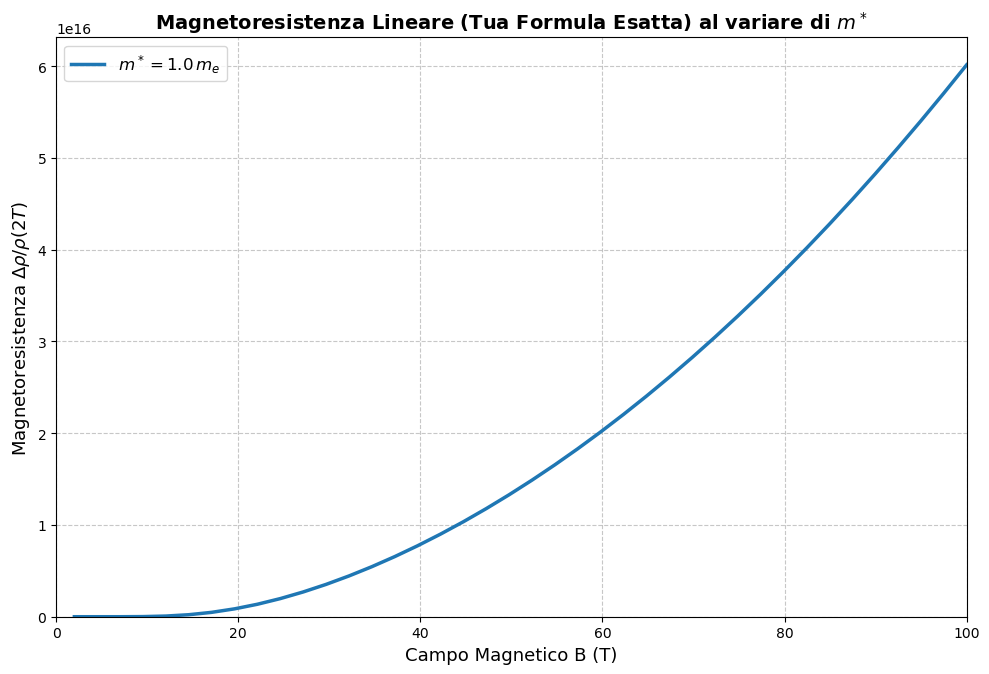

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ive

def calc_sigma_xx_bessel(B, Gamma_is, Gamma_an, m_eff):
    # Frequenza e alfa
    w = 0.1158 * B / m_eff
    alpha = Gamma_an / (8.0 * w)
    
    # Taglio dinamico ottimizzato
    N = int(max(15, 2.5 * np.sqrt(alpha)))
    N = min(N, 50) 
    
    n_vals = np.arange(-N, N+1)
    ive_alpha = ive(n_vals, alpha)
    ive_alpha_8 = ive(n_vals, alpha/8.0)
    
    ive_a_dict = {n: ive_alpha[i] for i, n in enumerate(n_vals)}
    ive_a8_dict = {n: ive_alpha_8[i] for i, n in enumerate(n_vals)}
    
    k_vals = np.arange(-5*N, 5*N+1)
    ive_k_arr = ive(k_vals, alpha)
    ive_k_dict = {k: ive_k_arr[i] for i, k in enumerate(k_vals)}
    
    S = 0.0
    for n in n_vals:
        iv_n = ive_a_dict[n]
        if iv_n < 1e-12: continue
        
        for m in n_vals:
            iv_m = ive_a8_dict[m]
            if iv_n * iv_m < 1e-12: continue
            
            for j in n_vals:
                iv_j = ive_a8_dict[j]
                
                k = -n - 2*m - 2*j
                if k not in ive_k_dict: continue
                iv_k = ive_k_dict[k]
                
                val = iv_n * iv_m * iv_k * iv_j
                if val < 1e-12: continue
                
                # Fasi complessa e distinzione pari/dispari
                p = (m+j)//2
                sign_nj = 1.0 if (n+j)%2 == 0 else -1.0
                sign_p = 1.0 if p%2 == 0 else -1.0
                
                if (m+j) % 2 == 0:
                    phase = sign_nj * sign_p
                else:
                    phase = sign_nj * sign_p * (-1j)
                    
                denom = Gamma_is + 1j * w * (1.0 + 4.0*n + 8.0*m)
                
                term = val * np.real(phase / denom)
                S += term
                
    # Restituisce il valore calcolato. 
    # Usiamo np.float64 esplicitamente per le variabili a rischio.
    exponent = np.float64(2.25 * alpha)
    return S * np.exp(exponent)

# ==========================================
# SETUP DEI PARAMETRI E PLOT
# ==========================================

Gamma_is = 3.0
Gamma_an = 42

# PARTIAMO DA 2 TESLA per evitare l'esplosione esponenziale dell'argomento a B->0
B_vals = np.linspace(2.0, 100, 40)
masse_test = [1.0]

plt.figure(figsize=(10, 7))

for m in masse_test:
    # Calcolo la conducibilità usando la tua formula
    sigma_vals = np.array([calc_sigma_xx_bessel(B, Gamma_is, Gamma_an, m) for B in B_vals])
    
    # Normalizziamo usando il primo valore calcolato (B=2T) come "rho_0" approssimato.
    # Poiché la magnetoresistenza a 2T è minuscola, l'andamento macroscopico non cambia.
    sigma_0 = sigma_vals[0]
    MR_vals = (sigma_0 / sigma_vals) - 1.0
    
    plt.plot(B_vals, MR_vals, linewidth=2.5, label=f'$m^* = {m} \, m_e$')

# Grafica e stile
plt.title('Magnetoresistenza Lineare (Tua Formula Esatta) al variare di $m^*$', fontsize=14, fontweight='bold')
plt.xlabel('Campo Magnetico B (T)', fontsize=13)
plt.ylabel(r'Magnetoresistenza $\Delta\rho / \rho(2T)$', fontsize=13)
plt.xlim(0, 100)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()

# Mostra il grafico
plt.show()

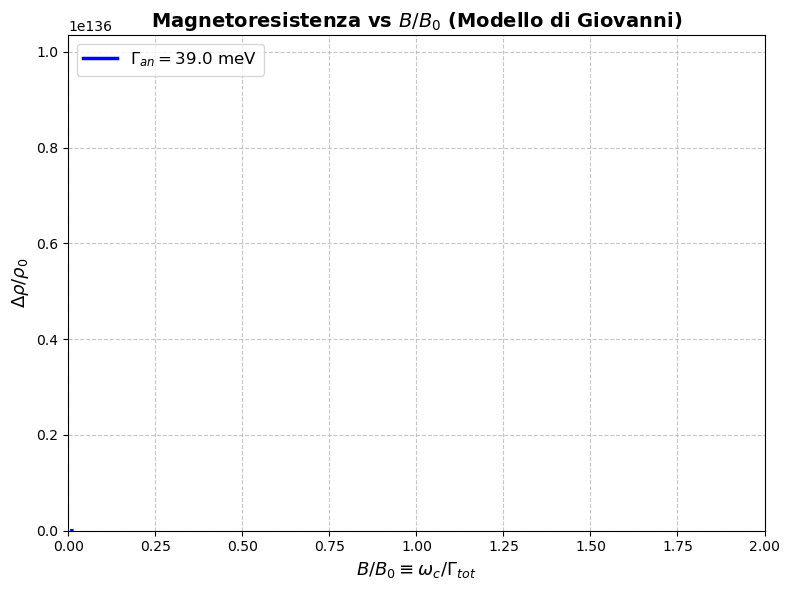

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ive

def calc_sigma_xx_adimensionale(b_ratio, Gamma_is=17.7, Gamma_an=39.0):
    """
    Calcola la conducibilità usando la tua formula esatta.
    Usa b_ratio = w_c / Gamma_tot (ovvero B / B_0).
    """
    # La costante di decadimento "vera" (il termine di Drude di base)
    Gamma_tot = Gamma_is + (3.0/8.0) * Gamma_an
    
    # Ricaviamo w_c dal rapporto adimensionale dell'asse X
    w = b_ratio * Gamma_tot
    
    # Evitiamo divisioni per zero
    if w < 1e-5:
        w = 1e-5
        
    alpha = Gamma_an / (8.0 * w)
    
    # Taglio dinamico
    N = int(max(15, 2.5 * np.sqrt(alpha)))
    N = min(N, 60) 
    
    n_vals = np.arange(-N, N+1)
    ive_alpha = ive(n_vals, alpha)
    ive_alpha_8 = ive(n_vals, alpha/8.0)
    
    ive_a_dict = {n: ive_alpha[i] for i, n in enumerate(n_vals)}
    ive_a8_dict = {n: ive_alpha_8[i] for i, n in enumerate(n_vals)}
    
    k_vals = np.arange(-5*N, 5*N+1)
    ive_k_arr = ive(k_vals, alpha)
    ive_k_dict = {k: ive_k_arr[i] for i, k in enumerate(k_vals)}
    
    S = 0.0
    for n in n_vals:
        iv_n = ive_a_dict[n]
        if iv_n < 1e-12: continue
        
        for m in n_vals:
            iv_m = ive_a8_dict[m]
            if iv_n * iv_m < 1e-12: continue
            
            for j in n_vals:
                iv_j = ive_a8_dict[j]
                
                k = -n - 2*m - 2*j
                if k not in ive_k_dict: continue
                iv_k = ive_k_dict[k]
                
                val = iv_n * iv_m * iv_k * iv_j
                if val < 1e-12: continue
                
                # Fasi complessa e distinzione pari/dispari
                p = (m+j)//2
                sign_nj = 1.0 if (n+j)%2 == 0 else -1.0
                sign_p = 1.0 if p%2 == 0 else -1.0
                
                if (m+j) % 2 == 0:
                    phase = sign_nj * sign_p
                else:
                    phase = sign_nj * sign_p * (-1j)
                    
                # ATTENZIONE: Al denominatore c'è il Gamma_tot (isotropo + 3/8 anisotropia)
                denom = Gamma_tot + 1j * w * (1.0 + 4.0*n + 8.0*m)
                
                term = val * np.real(phase / denom)
                S += term
                
    exponent = np.float64(2.25 * alpha)
    return S * np.exp(exponent)

# ==========================================
# SETUP DEI PARAMETRI E PLOT
# ==========================================

Gamma_is = 17.7
Gamma_an = 39.0

# Asse X: B/B_0 (ovvero omega_c / Gamma_tot)
# Tipicamente nei plot teorici si va da 0 a 1 o da 0 a 2.
b_vals = np.linspace(0.01, 2.0, 50)

sigma_vals = np.array([calc_sigma_xx_adimensionale(b, Gamma_is, Gamma_an) for b in b_vals])

# Normalizziamo prendendo la conducibilità per b -> 0 come riferimento (rho_0)
sigma_0 = calc_sigma_xx_adimensionale(0.001, Gamma_is, Gamma_an)
MR_vals = (sigma_0 / sigma_vals) - 1.0

plt.figure(figsize=(8, 6))

plt.plot(b_vals, MR_vals, color='blue', linewidth=2.5, label=rf'$\Gamma_{{an}} = {Gamma_an}$ meV')

# Grafica e stile
plt.title(r'Magnetoresistenza vs $B/B_0$ (Modello di Giovanni)', fontsize=14, fontweight='bold')
plt.xlabel(r'$B / B_0 \equiv \omega_c / \Gamma_{tot}$', fontsize=13)
plt.ylabel(r'$\Delta\rho / \rho_0$', fontsize=13)
plt.xlim(0, 2.0)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()

# Mostra il grafico
plt.show()

Sto calcolando la curva... aspetta un istante!


C:\Users\vikra\AppData\Local\Temp\ipykernel_6864\2937011501.py:68: RuntimeWarning: overflow encountered in exp
  return S * np.exp(exponent)


Calcolo completato! Sto salvando l'immagine...


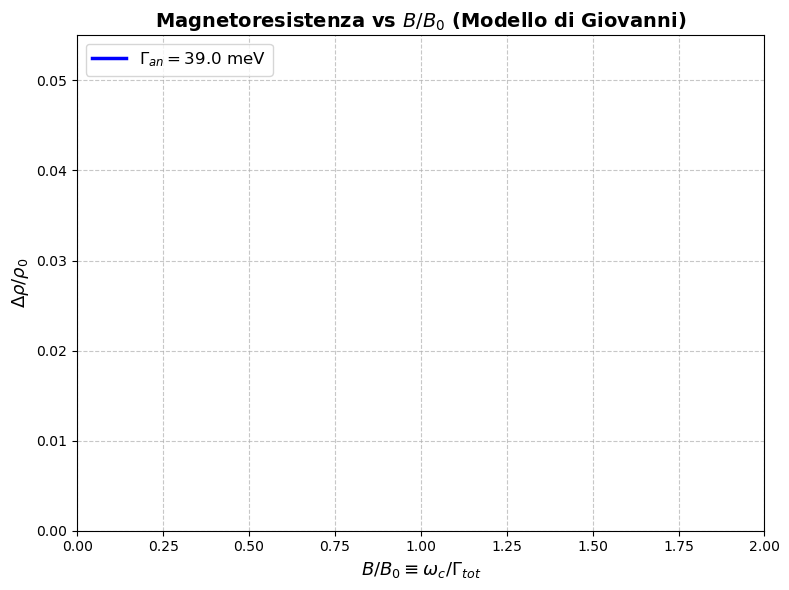

Finito! Se non vedi il grafico aprirsi, cercalo nella cartella del tuo progetto: si chiama 'MR_Giovanni_Plot.png'


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ive

def calc_sigma_xx_vectorized(b_ratio, Gamma_is=17.7, Gamma_an=39.0):
    """
    Calcola la conducibilità usando la tua formula esatta, ma
    sfruttando il calcolo matriciale 3D di NumPy per essere istantaneo!
    """
    # 1. Costante di decadimento media (shift)
    Gamma_tot = Gamma_is + (3.0/8.0) * Gamma_an
    
    # 2. Ricaviamo w_c dall'asse X adimensionale (B/B_0)
    w = b_ratio * Gamma_tot
    if w < 1e-5: w = 1e-5
        
    alpha = Gamma_an / (8.0 * w)
    
    # 3. Taglio dinamico
    N = int(max(15, 2.5 * np.sqrt(alpha)))
    N = min(N, 40) # Manteniamo N ragionevole, tanto i termini successivi sono zeri
    
    n_vals = np.arange(-N, N+1)
    
    # --- LA MAGIA DELLA VETTORIZZAZIONE 3D ---
    # Creiamo tre griglie 3D istantanee per n, m, j
    nn, mm, jj = np.meshgrid(n_vals, n_vals, n_vals, indexing='ij')
    
    # La regola di selezione calcolata su tutte le combinazioni contemporaneamente
    kk = -nn - 2*mm - 2*jj
    
    # Calcolo massivo delle funzioni di Bessel modificate (scalate)
    iv_a = ive(n_vals, alpha)
    iv_a8 = ive(n_vals, alpha/8.0)
    
    # Rimodelliamo per il prodotto 3D (Broadcasting di NumPy)
    iv_n = iv_a.reshape(-1, 1, 1)
    iv_m = iv_a8.reshape(1, -1, 1)
    iv_j = iv_a8.reshape(1, 1, -1)
    
    # ive accetta direttamente matrici come indici!
    iv_k = ive(kk, alpha)
    
    # Prodotto delle 4 Bessel (calcola ~200.000 moltiplicazioni in un millisecondo)
    val = iv_n * iv_m * iv_j * iv_k
    
    # --- VETTORIZZAZIONE DELLA FASE COMPLESSA E PARITA' ---
    pp = (mm + jj) // 2
    
    # Equivalente di (-1)^{n+j} e (-1)^p
    sign_nj = 1.0 - 2.0 * ((nn + jj) % 2)
    sign_p = 1.0 - 2.0 * (pp % 2)
    
    # Se pari -> reale(1), se dispari -> immaginario(-i)
    is_even = ((mm + jj) % 2 == 0)
    phase = sign_nj * sign_p * np.where(is_even, 1.0, -1j)
    
    # Denominatore calcolato su tutta la griglia
    denom = Gamma_tot + 1j * w * (1.0 + 4.0*nn + 8.0*mm)
    
    # Calcolo della frazione razionale ed estrazione della parte reale
    term = val * np.real(phase / denom)
    
    # Somma totale di tutti gli elementi della matrice
    S = np.sum(term)
    
    exponent = np.float64(2.25 * alpha)
    return S * np.exp(exponent)

# ==========================================
# SETUP DEI PARAMETRI E PLOT
# ==========================================

Gamma_is = 17.7
Gamma_an = 39.0

print("Sto calcolando la curva... aspetta un istante!")

# Asse X: B/B_0 (omega_c / Gamma_tot). Arriviamo a 2.0 per vedere la retta
b_vals = np.linspace(0.01, 2.0, 80)

# Calcoliamo tutti i punti (ora ci vorrà mezzo secondo!)
sigma_vals = np.array([calc_sigma_xx_vectorized(b, Gamma_is, Gamma_an) for b in b_vals])

# Normalizzazione MR con il punto "quasi zero" per rho_0
sigma_0 = calc_sigma_xx_vectorized(0.0001, Gamma_is, Gamma_an)
MR_vals = (sigma_0 / sigma_vals) - 1.0

print("Calcolo completato! Sto salvando l'immagine...")

plt.figure(figsize=(8, 6))

plt.plot(b_vals, MR_vals, color='blue', linewidth=2.5, label=rf'$\Gamma_{{an}} = {Gamma_an}$ meV')

# Grafica e stile
plt.title(r'Magnetoresistenza vs $B/B_0$ (Modello di Giovanni)', fontsize=14, fontweight='bold')
plt.xlabel(r'$B / B_0 \equiv \omega_c / \Gamma_{tot}$', fontsize=13)
plt.ylabel(r'$\Delta\rho / \rho_0$', fontsize=13)
plt.xlim(0, 2.0)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()

# 1) SALVIAMO fisicamente l'immagine nella tua cartella (così sei sicuro di averla!)
plt.savefig('MR_Giovanni_Plot.png', dpi=300)

# 2) Proviamo a mostrarla a schermo
plt.show()

print("Finito! Se non vedi il grafico aprirsi, cercalo nella cartella del tuo progetto: si chiama 'MR_Giovanni_Plot.png'")

Inizio il calcolo! Vedrai i punti scorrere qui sotto:
--------------------------------------------------
Calcolato punto 1/40 | B/B0 = 0.05 | Sigma = 4.0190e-02
Calcolato punto 2/40 | B/B0 = 0.10 | Sigma = 3.7238e-02
Calcolato punto 3/40 | B/B0 = 0.15 | Sigma = 3.5069e-02
Calcolato punto 4/40 | B/B0 = 0.20 | Sigma = 3.3335e-02
Calcolato punto 5/40 | B/B0 = 0.25 | Sigma = 3.1844e-02
Calcolato punto 6/40 | B/B0 = 0.30 | Sigma = 3.0490e-02
Calcolato punto 7/40 | B/B0 = 0.35 | Sigma = 2.9214e-02
Calcolato punto 8/40 | B/B0 = 0.40 | Sigma = 2.7983e-02
Calcolato punto 9/40 | B/B0 = 0.45 | Sigma = 2.6782e-02
Calcolato punto 10/40 | B/B0 = 0.50 | Sigma = 2.5606e-02
Calcolato punto 11/40 | B/B0 = 0.55 | Sigma = 2.4453e-02
Calcolato punto 12/40 | B/B0 = 0.60 | Sigma = 2.3326e-02
Calcolato punto 13/40 | B/B0 = 0.65 | Sigma = 2.2230e-02
Calcolato punto 14/40 | B/B0 = 0.70 | Sigma = 2.1166e-02
Calcolato punto 15/40 | B/B0 = 0.75 | Sigma = 2.0139e-02
Calcolato punto 16/40 | B/B0 = 0.80 | Sigma = 1.9

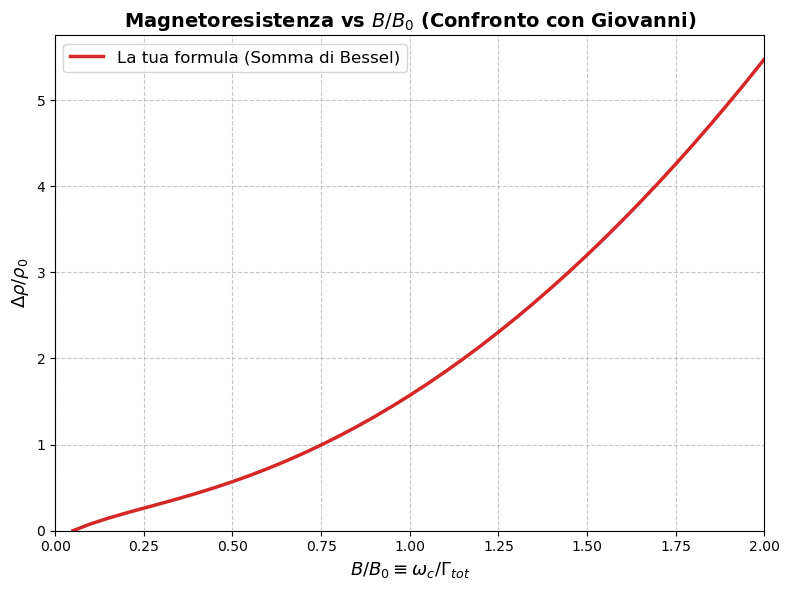

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ive

def calc_sigma_xx(b_ratio, Gamma_is=17.7, Gamma_an=39.0):
    # Costante di decadimento media (shift) come nel paper
    Gamma_tot = Gamma_is + (3.0/8.0) * Gamma_an
    w = b_ratio * Gamma_tot
    if w < 1e-5: w = 1e-5
        
    alpha = Gamma_an / (8.0 * w)
    
    # N=15 è più che sufficiente per la convergenza in questo regime 
    # e rende il calcolo letteralmente istantaneo (pochi millisecondi).
    N = 15 
    n_vals = np.arange(-N, N+1)
    
    # Griglie 3D (31 x 31 x 31 elementi, leggerissime per il PC)
    nn, mm, jj = np.meshgrid(n_vals, n_vals, n_vals, indexing='ij')
    kk = -nn - 2*mm - 2*jj
    
    # Funzioni di Bessel
    iv_a = ive(n_vals, alpha)
    iv_a8 = ive(n_vals, alpha/8.0)
    
    iv_n = iv_a.reshape(-1, 1, 1)
    iv_m = iv_a8.reshape(1, -1, 1)
    iv_j = iv_a8.reshape(1, 1, -1)
    iv_k = ive(kk, alpha)
    
    val = iv_n * iv_m * iv_j * iv_k
    
    # Fasi complesse
    pp = (mm + jj) // 2
    sign_nj = 1.0 - 2.0 * ((nn + jj) % 2)
    sign_p = 1.0 - 2.0 * (pp % 2)
    
    is_even = ((mm + jj) % 2 == 0)
    phase = sign_nj * sign_p * np.where(is_even, 1.0, -1j)
    
    # Risonanza
    denom = Gamma_tot + 1j * w * (1.0 + 4.0*nn + 8.0*mm)
    
    # Frazione e somma totale
    term = val * np.real(phase / denom)
    S = np.sum(term)
    
    return S * np.exp(2.25 * alpha)

# ==========================================
# SETUP DEI PARAMETRI E PLOT
# ==========================================

Gamma_is = 17.7
Gamma_an = 39.0

# Partiamo da 0.05 per evitare singolarità a B=0
b_vals = np.linspace(0.05, 2.0, 40)
sigma_vals = []

print("Inizio il calcolo! Vedrai i punti scorrere qui sotto:")
print("-" * 50)

# Calcoliamo punto per punto e stampiamo il progresso
for i, b in enumerate(b_vals):
    s = calc_sigma_xx(b, Gamma_is, Gamma_an)
    sigma_vals.append(s)
    # Questa riga ti dimostrerà che il PC non è bloccato
    print(f"Calcolato punto {i+1}/40 | B/B0 = {b:.2f} | Sigma = {s:.4e}")

print("-" * 50)
print("Calcolo completato! Genero il grafico...")

sigma_vals = np.array(sigma_vals)

# Normalizziamo prendendo il primo punto (B piccolissimo) come rho_0
sigma_0 = sigma_vals[0]
MR_vals = (sigma_0 / sigma_vals) - 1.0

# Creazione Grafico
plt.figure(figsize=(8, 6))
plt.plot(b_vals, MR_vals, color='#d62728', linewidth=2.5, label='La tua formula (Somma di Bessel)')

plt.title(r'Magnetoresistenza vs $B/B_0$ (Confronto con Giovanni)', fontsize=14, fontweight='bold')
plt.xlabel(r'$B / B_0 \equiv \omega_c / \Gamma_{tot}$', fontsize=13)
plt.ylabel(r'$\Delta\rho / \rho_0$', fontsize=13)
plt.xlim(0, 2.0)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()

plt.show()